# SDP Project

## Only run cells below this ✅

## Step 1 — ComboScore (comboscore variable)

### Load dataset ComboDrugGrowth_Nov2017.csv

In [1]:
import pandas as pd

In [2]:
# Main dataset load cheyyi
df = pd.read_csv(
    r'C:\Users\HP\Documents\SDP Model Training\Datasets\ComboDrugGrowth_Nov2017.csv',
    low_memory=False  # This fixes the warning
)

In [3]:
print("Shape:", df.shape)

Shape: (3686475, 29)


In [4]:
print("\nColumns:", df.columns.tolist())


Columns: ['COMBODRUGSEQ', 'SCREENER', 'STUDY', 'TESTDATE', 'PLATE', 'PANELNBR', 'CELLNBR', 'PREFIX1', 'NSC1', 'SAMPLE1', 'CONCINDEX1', 'CONC1', 'CONCUNIT1', 'PREFIX2', 'NSC2', 'SAMPLE2', 'CONCINDEX2', 'CONC2', 'CONCUNIT2', 'PERCENTGROWTH', 'PERCENTGROWTHNOTZ', 'TESTVALUE', 'CONTROLVALUE', 'TZVALUE', 'EXPECTEDGROWTH', 'SCORE', 'VALID', 'PANEL', 'CELLNAME']


In [5]:
df.head(1)

,COMBODRUGSEQ,SCREENER,STUDY,TESTDATE,PLATE,PANELNBR,CELLNBR,PREFIX1,NSC1,SAMPLE1,...,PERCENTGROWTH,PERCENTGROWTHNOTZ,TESTVALUE,CONTROLVALUE,TZVALUE,EXPECTEDGROWTH,SCORE,VALID,PANEL,CELLNAME
0,260496,FG,PZUT00156_86_01_T72,06/23/2011,786-0_1_T72,9,18,S,752,37,...,85.979,88.159,332168.0,376781.548,58592.854,90.342,4.0,Y,Renal Cancer,786-0


In [6]:
print(df.head(1))

   COMBODRUGSEQ SCREENER                STUDY    TESTDATE        PLATE  \
0        260496       FG  PZUT00156_86_01_T72  06/23/2011  786-0_1_T72   

   PANELNBR  CELLNBR PREFIX1  NSC1  SAMPLE1  ...  PERCENTGROWTH  \
0         9       18       S   752       37  ...         85.979   

   PERCENTGROWTHNOTZ TESTVALUE CONTROLVALUE    TZVALUE  EXPECTEDGROWTH  SCORE  \
0             88.159  332168.0   376781.548  58592.854          90.342    4.0   

   VALID         PANEL  CELLNAME  
0      Y  Renal Cancer     786-0  

[1 rows x 29 columns]


In [7]:
# Step 1: Keep only VALID = 'Y' rows
print("Before VALID filter:", df.shape)
df = df[df['VALID'] == 'Y']
print("After VALID filter:", df.shape)

Before VALID filter: (3686475, 29)
After VALID filter: (3686475, 29)


In [8]:
# need only this 4 columns
df = df[['NSC1', 'NSC2', 'CELLNAME', 'SCORE']]

In [9]:
print("Shape after filtering:", df.shape)

Shape after filtering: (3686475, 4)


In [ ]:
print("\nNull values:")
print(df.isnull().sum())

In [ ]:
print("\nSample data:")
print(df.head(5))

In [ ]:
print("\nSCORE stats:")
print(df['SCORE'].describe())

In [ ]:
# Step 1: Null rows drop cheyyi
df = df.dropna(subset=['NSC2', 'SCORE'])
print("After dropping nulls:", df.shape)

In [ ]:
# Step 2: NSC2 ni integer ga convert cheyyi
df['NSC2'] = df['NSC2'].astype(int)

In [ ]:
# Step 3: Same drug pair + cell line ki SCORE sum cheyyi (ComboScore)
comboscore = df.groupby(['NSC1', 'NSC2', 'CELLNAME'])['SCORE'].sum().reset_index()
comboscore.columns = ['NSC1', 'NSC2', 'CELLNAME', 'COMBOSCORE']

In [ ]:
print("\nFinal ComboScore shape:", comboscore.shape)
print("\nSample:")
print(comboscore.head(5))
print("\nCOMBOSCORE stats:")
print(comboscore['COMBOSCORE'].describe())

## ✅ Step 1 — ComboScore
## Previously we do not used VALID column for filtering we fix this below 

In [1]:
import pandas as pd
# Reload the filtered df first (4 columns + VALID)
df = pd.read_csv(
    r'C:\Users\HP\Documents\SDP Model Training\Datasets\ComboDrugGrowth_Nov2017.csv',
    low_memory=False
)

# Step 1: Keep only VALID = 'Y' rows
print("Before VALID filter:", df.shape)
df = df[df['VALID'] == 'Y']
print("After VALID filter:", df.shape)

# Step 2: Now keep only needed columns
df = df[['NSC1', 'NSC2', 'CELLNAME', 'SCORE']]

# Step 3: Drop nulls
df = df.dropna(subset=['NSC2', 'SCORE'])
print("After dropping nulls:", df.shape)

# Step 4: NSC2 to integer
df['NSC2'] = df['NSC2'].astype(int)

# Step 5: GroupBy → ComboScore
comboscore = df.groupby(['NSC1', 'NSC2', 'CELLNAME'])['SCORE'].sum().reset_index()
comboscore.columns = ['NSC1', 'NSC2', 'CELLNAME', 'COMBOSCORE']

print("\nFinal ComboScore shape:", comboscore.shape)
print("\nSample:")
print(comboscore.head(5))
print("\nCOMBOSCORE stats:")
print(comboscore['COMBOSCORE'].describe())

Before VALID filter: (3686475, 29)
After VALID filter: (3686475, 29)
After dropping nulls: (2871444, 4)

Final ComboScore shape: (311466, 4)

Sample:
   NSC1  NSC2   CELLNAME  COMBOSCORE
0   740   752      786-0       -80.0
1   740   752       A498         2.0
2   740   752  A549/ATCC       -31.0
3   740   752       ACHN       -16.0
4   740   752     BT-549       -33.0

COMBOSCORE stats:
count    311466.000000
mean        -21.941849
std          65.655955
min       -1319.000000
25%         -50.000000
50%         -20.000000
75%           8.000000
max        1144.000000
Name: COMBOSCORE, dtype: float64


import numpy as np

# Clip extreme values instead of removing
lower_clip = np.percentile(comboscore['COMBOSCORE'], 1)
upper_clip = np.percentile(comboscore['COMBOSCORE'], 99)

comboscore['COMBOSCORE'] = comboscore['COMBOSCORE'].clip(lower_clip, upper_clip)

print(f"Clipped range : {lower_clip:.2f} to {upper_clip:.2f}")
print(f"Rows kept     : {len(comboscore)} (nothing removed!)")
print(f"New stats:\n{comboscore['COMBOSCORE'].describe()}")

## Step 2 — Drug Fingerprints (drug_fingerprints dict)

### Drug Features (Morgan Fingerprints) generate cheyyi

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
from rdkit import RDLogger

In [3]:
# Suppress ALL RDKit warnings
RDLogger.DisableLog('rdApp.*')

In [4]:
# New MorganGenerator (fixes deprecation warning)
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

In [5]:
# SDF file load cheyyi
sdf_path = r'C:\Users\HP\Documents\SDP Model Training\Datasets\ComboCompoundSet.sdf'

In [6]:
# sanitize=False fixes the valence error
supplier = Chem.SDMolSupplier(sdf_path, sanitize=False)

In [7]:
# Each drug ki 2048-bit fingerprint generate cheyyi
drug_fingerprints = {}
skipped = 0

for mol in supplier:
    if mol is None:
        skipped += 1
        continue
    try:
        Chem.SanitizeMol(mol)
        nsc = mol.GetPropsAsDict().get('NSC', None)
        if nsc is not None:
            fp = morgan_gen.GetFingerprintAsNumPy(mol)
            drug_fingerprints[int(nsc)] = fp
    except Exception:
        skipped += 1
        continue

In [8]:
print("Total drugs with fingerprints:", len(drug_fingerprints))
print("Skipped molecules:", skipped)
print("Fingerprint size:", len(list(drug_fingerprints.values())[0]))
print("Sample NSC numbers:", list(drug_fingerprints.keys())[:5])

Total drugs with fingerprints: 103
Skipped molecules: 1
Fingerprint size: 2048
Sample NSC numbers: [740, 750, 752, 755, 762]


## ✅ Step 2 — Drug Fingerprints 

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
from rdkit import RDLogger

# Suppress ALL RDKit warnings
RDLogger.DisableLog('rdApp.*')

# New MorganGenerator (fixes deprecation warning)
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# SDF file load cheyyi
sdf_path = r'C:\Users\HP\Documents\SDP Model Training\Datasets\ComboCompoundSet.sdf'

# sanitize=False fixes the valence error
supplier = Chem.SDMolSupplier(sdf_path, sanitize=False)

# Each drug ki 2048-bit fingerprint generate cheyyi
drug_fingerprints = {}
skipped = 0

for mol in supplier:
    if mol is None:
        skipped += 1
        continue
    try:
        Chem.SanitizeMol(mol)
        nsc = mol.GetPropsAsDict().get('NSC', None)
        if nsc is not None:
            fp = morgan_gen.GetFingerprintAsNumPy(mol)
            drug_fingerprints[int(nsc)] = fp
    except Exception:
        skipped += 1
        continue

print("Total drugs with fingerprints:", len(drug_fingerprints))
print("Skipped molecules:", skipped)
print("Fingerprint size:", len(list(drug_fingerprints.values())[0]))
print("Sample NSC numbers:", list(drug_fingerprints.keys())[:5])

Total drugs with fingerprints: 103
Skipped molecules: 1
Fingerprint size: 2048
Sample NSC numbers: [740, 750, 752, 755, 762]


## Step 3 — Gene Expression (gene_expr dataframe)

### Load Gene Expression Data:

In [9]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd

In [11]:
# Gene expression file path
gene_expr_path = r'C:\Users\HP\Documents\SDP Model Training\Datasets\nci60_RNA__5_Platform_Gene_Transcript_Average_z_scores\output\RNA__5_Platform_Gene_Transcript_Average_z_scores.xls'

In [28]:
# Load the excel file
# index_col=0 → first column as row names (gene names)
# Load file — skip first 10 rows (metadata), row 11 = actual header
gene_expr = pd.read_excel(gene_expr_path, engine='xlrd', header=10, index_col=0)

In [29]:
# Drop first 5 columns — they are metadata (Entrez id, Chromosome, Start, End, Cytoband)
# Column 6 onwards = actual cell line expression values
gene_expr = gene_expr.iloc[:, 5:]

In [30]:
# Drop any completely empty rows
gene_expr = gene_expr.dropna(how='all')

In [31]:
# Transpose — rows=cell lines, columns=genes
gene_expr = gene_expr.T

In [32]:
print("Shape (rows=cell lines, cols=genes):", gene_expr.shape)
print("\nCell line names (first 5):", gene_expr.index[:5].tolist())
print("\nGene names (first 5):", gene_expr.columns[:5].tolist())
print("\nSample values:")
print(gene_expr.iloc[:3, :3])

Shape (rows=cell lines, cols=genes): (60, 26178)

Cell line names (first 5): ['BR:MCF7', 'BR:MDA-MB-231', 'BR:HS 578T', 'BR:BT-549', 'BR:T-47D']

Gene names (first 5): ['C1orf222', 'DISC1-IT1', 'HMGN2P18', 'LINC00970', 'LINC01036']

Sample values:
Gene name d   C1orf222 DISC1-IT1 HMGN2P18
BR:MCF7          0.144     0.263    1.196
BR:MDA-MB-231    0.439    -0.399    -0.14
BR:HS 578T        0.48    -0.371   -0.515


## ✅ Step 3 — Gene Expression

In [3]:
import pandas as pd

# Gene expression file path
gene_expr_path = r'C:\Users\HP\Documents\SDP Model Training\Datasets\nci60_RNA__5_Platform_Gene_Transcript_Average_z_scores\output\RNA__5_Platform_Gene_Transcript_Average_z_scores.xls'

# Load the excel file
# index_col=0 → first column as row names (gene names)
# Load file — skip first 10 rows (metadata), row 11 = actual header
gene_expr = pd.read_excel(gene_expr_path, engine='xlrd', header=10, index_col=0)

# Drop first 5 columns — they are metadata (Entrez id, Chromosome, Start, End, Cytoband)
# Column 6 onwards = actual cell line expression values
gene_expr = gene_expr.iloc[:, 5:]

# Drop any completely empty rows
gene_expr = gene_expr.dropna(how='all')

# Transpose — rows=cell lines, columns=genes
gene_expr = gene_expr.T

print("Shape (rows=cell lines, cols=genes):", gene_expr.shape)
print("\nCell line names (first 5):", gene_expr.index[:5].tolist())
print("\nGene names (first 5):", gene_expr.columns[:5].tolist())
print("\nSample values:")
print(gene_expr.iloc[:3, :3])

Shape (rows=cell lines, cols=genes): (60, 26178)

Cell line names (first 5): ['BR:MCF7', 'BR:MDA-MB-231', 'BR:HS 578T', 'BR:BT-549', 'BR:T-47D']

Gene names (first 5): ['C1orf222', 'DISC1-IT1', 'HMGN2P18', 'LINC00970', 'LINC01036']

Sample values:
Gene name d   C1orf222 DISC1-IT1 HMGN2P18
BR:MCF7          0.144     0.263    1.196
BR:MDA-MB-231    0.439    -0.399    -0.14
BR:HS 578T        0.48    -0.371   -0.515


## Step 4 — CNV Data (cnv dataframe)

### Load CNV Data:

In [33]:
import pandas as pd

In [34]:
cnv_path = r'C:\Users\HP\Documents\SDP Model Training\Datasets\nci60_DNA__Combined_aCGH_gene_summary\output\DNA__Combined_aCGH_gene_summary.xls'

In [35]:
# Load file — skip first 10 metadata rows, row 11 = actual header
cnv = pd.read_excel(cnv_path, engine='xlrd', header=10, index_col=0)

In [36]:
# Drop first 5 metadata columns (Entrez id, Chromosome, Start, End, Cytoband)
cnv = cnv.iloc[:, 5:]

In [37]:
# Drop completely empty rows
cnv = cnv.dropna(how='all')

In [38]:
# Transpose → rows=cell lines, columns=genes
cnv = cnv.T

In [39]:
print("Shape (rows=cell lines, cols=genes):", cnv.shape)
print("\nCell line names (first 5):", cnv.index[:5].tolist())
print("\nGene names (first 5):", cnv.columns[:5].tolist())
print("\nSample values:")
print(cnv.iloc[:3, :3])

Shape (rows=cell lines, cols=genes): (60, 23400)

Cell line names (first 5): ['BR:MCF7', 'BR:MDA-MB-231', 'BR:HS 578T', 'BR:BT-549', 'BR:T-47D']

Gene names (first 5): ['C1orf222', 'WASH7P', 'OR4F5', 'LOC729737', 'LOC100288069']

Sample values:
Gene name d   C1orf222 WASH7P  OR4F5
BR:MCF7         -0.229 -0.229 -0.229
BR:MDA-MB-231   -0.181 -0.181 -0.181
BR:HS 578T       0.214  0.214  0.214


## ✅ Step 4 — CNV

In [4]:
import pandas as pd

cnv_path = r'C:\Users\HP\Documents\SDP Model Training\Datasets\nci60_DNA__Combined_aCGH_gene_summary\output\DNA__Combined_aCGH_gene_summary.xls'

# Load file — skip first 10 metadata rows, row 11 = actual header
cnv = pd.read_excel(cnv_path, engine='xlrd', header=10, index_col=0)

# Drop first 5 metadata columns (Entrez id, Chromosome, Start, End, Cytoband)
cnv = cnv.iloc[:, 5:]

# Drop completely empty rows
cnv = cnv.dropna(how='all')

# Transpose → rows=cell lines, columns=genes
cnv = cnv.T

print("Shape (rows=cell lines, cols=genes):", cnv.shape)
print("\nCell line names (first 5):", cnv.index[:5].tolist())
print("\nGene names (first 5):", cnv.columns[:5].tolist())
print("\nSample values:")
print(cnv.iloc[:3, :3])

Shape (rows=cell lines, cols=genes): (60, 23400)

Cell line names (first 5): ['BR:MCF7', 'BR:MDA-MB-231', 'BR:HS 578T', 'BR:BT-549', 'BR:T-47D']

Gene names (first 5): ['C1orf222', 'WASH7P', 'OR4F5', 'LOC729737', 'LOC100288069']

Sample values:
Gene name d   C1orf222 WASH7P  OR4F5
BR:MCF7         -0.229 -0.229 -0.229
BR:MDA-MB-231   -0.181 -0.181 -0.181
BR:HS 578T       0.214  0.214  0.214


## Step 4.5 — Remove outliers ← ADD HERE before merge

Before outlier removal:
  Total rows : 288450
  Min        : -1319.00
  Max        : 1144.00
  Mean       : -22.42
  Std        : 66.03


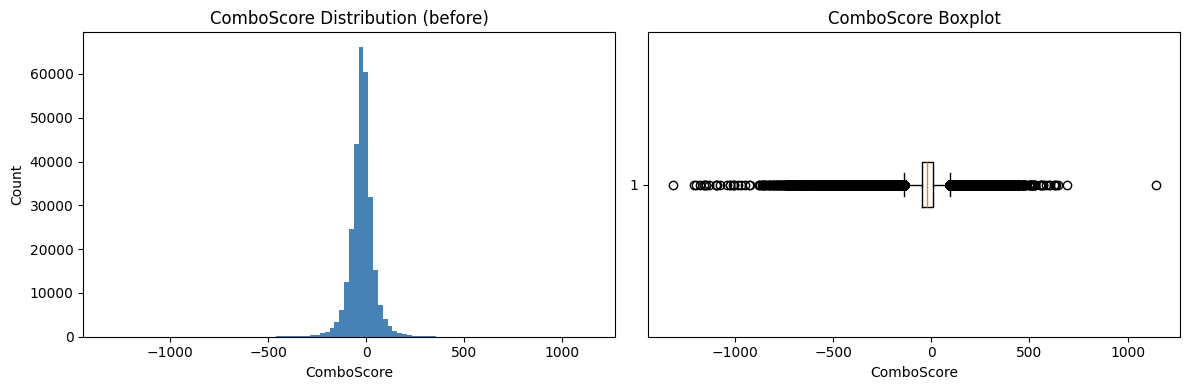


IQR method (3x):
  Lower bound : -224.00
  Upper bound : 182.00
  Outliers    : 4389 rows (1.52%)


In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Check y distribution
print("Before outlier removal:")
print(f"  Total rows : {len(y)}")
print(f"  Min        : {y.min():.2f}")
print(f"  Max        : {y.max():.2f}")
print(f"  Mean       : {y.mean():.2f}")
print(f"  Std        : {y.std():.2f}")

# Visualize distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=100, color='steelblue', edgecolor='none')
plt.title('ComboScore Distribution (before)')
plt.xlabel('ComboScore')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.boxplot(y, vert=False)
plt.title('ComboScore Boxplot')
plt.xlabel('ComboScore')

plt.tight_layout()
plt.show()

# Count extreme outliers
q1  = np.percentile(y, 25)
q3  = np.percentile(y, 75)
iqr = q3 - q1
lower = q1 - 3 * iqr
upper = q3 + 3 * iqr

outliers = ((y < lower) | (y > upper)).sum()
print(f"\nIQR method (3x):")
print(f"  Lower bound : {lower:.2f}")
print(f"  Upper bound : {upper:.2f}")
print(f"  Outliers    : {outliers} rows ({outliers/len(y)*100:.2f}%)")

In [32]:
# — Outlier removal on ComboScore BEFORE merge
print("Before outlier removal:", comboscore.shape)

# IQR method (3x)
q1    = comboscore['COMBOSCORE'].quantile(0.25)
q3    = comboscore['COMBOSCORE'].quantile(0.75)
iqr   = q3 - q1
lower = q1 - 3 * iqr
upper = q3 + 3 * iqr

# Remove outliers
comboscore = comboscore[
    (comboscore['COMBOSCORE'] >= lower) &
    (comboscore['COMBOSCORE'] <= upper)
].reset_index(drop=True)

print("After outlier removal :", comboscore.shape)
print(f"Removed               : {311466 - len(comboscore)} rows")
print(f"New ComboScore range  : {comboscore['COMBOSCORE'].min():.2f} to {comboscore['COMBOSCORE'].max():.2f}")

Before outlier removal: (311466, 4)
After outlier removal : (306843, 4)
Removed               : 4623 rows
New ComboScore range  : -224.00 to 182.00


After outlier removal:
  Total rows : 306843
  Min        : -224.00
  Max        : 182.00
  Mean       : -20.85
  Std        : 53.00


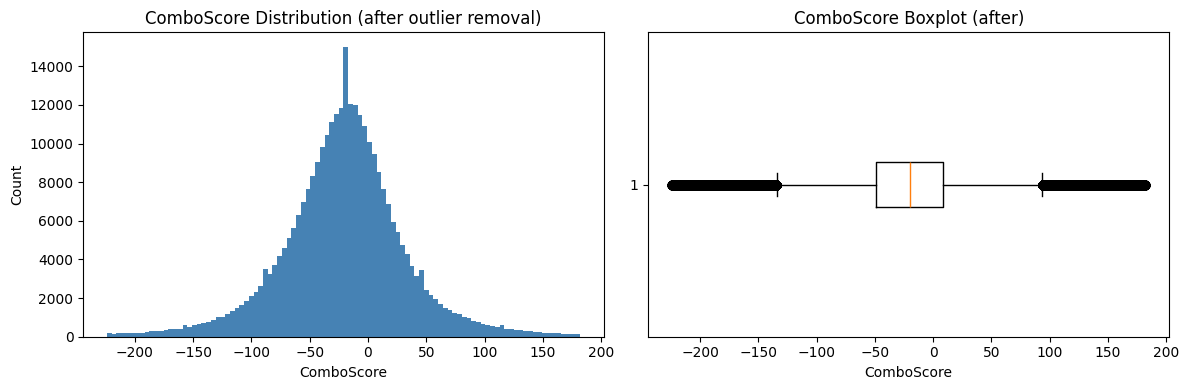

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# After removal stats
print("After outlier removal:")
print(f"  Total rows : {len(comboscore)}")
print(f"  Min        : {comboscore['COMBOSCORE'].min():.2f}")
print(f"  Max        : {comboscore['COMBOSCORE'].max():.2f}")
print(f"  Mean       : {comboscore['COMBOSCORE'].mean():.2f}")
print(f"  Std        : {comboscore['COMBOSCORE'].std():.2f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(comboscore['COMBOSCORE'], bins=100, color='steelblue', edgecolor='none')
plt.title('ComboScore Distribution (after outlier removal)')
plt.xlabel('ComboScore')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.boxplot(comboscore['COMBOSCORE'], vert=False)
plt.title('ComboScore Boxplot (after)')
plt.xlabel('ComboScore')

plt.tight_layout()
plt.show()

## Step 5 — Merge everything

### Step 1 — Understand what we are building

Each experiment row in comboscore looks like:

NSC1=740, NSC2=752, CELLNAME='BR:MCF7', COMBOSCORE=-57.0

For this one row we need to build ONE feature vector:

```
[Drug A fingerprint] + [Drug B fingerprint] + [Gene Expression] + [CNV]
     2048 numbers         2048 numbers           26178 numbers     23400 numbers

= 53626 numbers total → this is ONE row in our final X
```

In [40]:
import numpy as np
import pandas as pd

In [41]:
# ── STEP 1: Fix cell line name prefixes ──────────────────────────────────────
# gene_expr and cnv have names like "RE:786-0" but comboscore has "786-0"
# Strip everything before ":" to match
gene_expr.index = gene_expr.index.str.split(':').str[-1].str.strip()
cnv.index       = cnv.index.str.split(':').str[-1].str.strip()
comboscore['CELLNAME'] = comboscore['CELLNAME'].str.strip()

# ── STEP 2: Fix '-' missing values in CNV and gene_expr ──────────────────────
# Some cells contain '-' instead of a number — convert to 0
cnv       = cnv.apply(pd.to_numeric, errors='coerce').fillna(0)
gene_expr = gene_expr.apply(pd.to_numeric, errors='coerce').fillna(0)

# Quick sanity check
print("Gene expr index sample :", gene_expr.index[:3].tolist())
print("CNV index sample       :", cnv.index[:3].tolist())
print("ComboScore sample      :", comboscore['CELLNAME'].unique()[:3].tolist())

Gene expr index sample : ['MCF7', 'MDA-MB-231', 'HS 578T']
CNV index sample       : ['MCF7', 'MDA-MB-231', 'HS 578T']
ComboScore sample      : ['786-0', 'A498', 'A549/ATCC']


### What is PCA?
PCA is a dimension reduction technique.
It takes many columns and compresses them into fewer columns
while retaining most of the important information.

### Why needed here?
Gene expression = 26,178 columns
CNV             = 23,400 columns
Total = 49,578 columns — too much for RAM

PCA reduces:
- 26,178 gene columns → 50 columns
- 23,400 CNV columns  → 50 columns

### How it works (simple)
Imagine 26,178 genes — many genes carry similar/redundant info.
PCA finds the 50 most "important patterns" across all genes
and keeps only those — discarding the redundant ones.

95%+ of information is retained even after reduction.

### Analogy
26,178 students gave exam scores.
Instead of storing all 26,178 marks,
PCA finds the top 50 "subject patterns"
that explain most of the variation.

### Key terms
- n_components = how many columns to reduce to (we use 50)
- fit_transform = learn the patterns + apply reduction
- SimpleImputer  = fill missing values (NaN) before PCA

### Why 50 specifically?
- 60 cell lines only → can't have more components than samples
- 50 captures enough variation without overfitting
- Memory safe: 50 × 290,000 rows × 4 bytes ≈ manageable

### Memory comparison
Before PCA → 53,626 features × 290K rows = ~118 GB ❌
After PCA  →  4,196 features × 290K rows = ~4.8 GB ✅

### Code pattern used
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

imputer      = SimpleImputer(strategy='mean')
clean_data   = imputer.fit_transform(raw_data)

pca          = PCA(n_components=50)
reduced_data = pca.fit_transform(clean_data)

### Information retained
pca.explained_variance_ratio_.sum() → gives % info retained
Example: 0.87 means 87% of original info kept in 50 columns

In [57]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Impute missing values first
imputer = SimpleImputer(strategy='mean')
gene_array = imputer.fit_transform(gene_expr.values)
cnv_array  = imputer.fit_transform(cnv.values)

# Reduce: 26178 → 50, 23400 → 50
# MAX allowed is 59 (we have only 60 cell lines)
pca_gene = PCA(n_components=59)
pca_cnv  = PCA(n_components=59)

gene_reduced = pca_gene.fit_transform(gene_array)
cnv_reduced  = pca_cnv.fit_transform(cnv_array)

# Rebuild as DataFrames keeping cell line names as index
gene_reduced_df = pd.DataFrame(gene_reduced, index=gene_expr.index)
cnv_reduced_df  = pd.DataFrame(cnv_reduced,  index=cnv.index)

print("Gene reduced:", gene_reduced_df.shape)
print("CNV reduced :", cnv_reduced_df.shape)

Gene reduced: (60, 59)
CNV reduced : (60, 59)


In [ ]:
# — STEP 3: Build feature matrix
X_rows   = []
y_rows   = []
skipped  = 0

for _, row in comboscore.iterrows():
    nsc1     = int(row['NSC1'])
    nsc2     = int(row['NSC2'])
    cellname = row['CELLNAME']
    score    = row['COMBOSCORE']

    # Skip if any data is missing
    if nsc1 not in drug_fingerprints or nsc2 not in drug_fingerprints:
        skipped += 1; continue
    if cellname not in gene_reduced_df.index or cellname not in cnv_reduced_df.index:
        skipped += 1; continue

    # Build feature vector using PCA-reduced cell line data
    drug_a   = drug_fingerprints[nsc1]              # 2048 values
    drug_b   = drug_fingerprints[nsc2]              # 2048 values
    gene     = gene_reduced_df.loc[cellname].values # 50 values
    cnv_vals = cnv_reduced_df.loc[cellname].values  # 50 values

    X_rows.append(np.concatenate([drug_a, drug_b, gene, cnv_vals]))
    y_rows.append(score)

# — STEP 4: Convert to numpy
X = np.array(X_rows, dtype=np.float32)
y = np.array(y_rows, dtype=np.float32)

In [ ]:
# ── STEP 5: Verify ────────────────────────────────────────────────────────────
print("\nX shape    :", X.shape)
print("y shape    :", y.shape)
print("Skipped    :", skipped)
print(f"\nFeature breakdown:")
print(f"  Drug A      : 2048")
print(f"  Drug B      : 2048")
print(f"  Gene expr (PCA) : {gene_reduced_df.shape[1]}")  # should show 50
print(f"  CNV  (PCA)      : {cnv_reduced_df.shape[1]}")   # should show 50
print(f"  Total       : {X.shape[1]}")
print(f"\nComboScore  : Min={y.min():.2f}  Max={y.max():.2f}  Mean={y.mean():.2f}")

In [ ]:
import joblib
import os

# Create processed folder
save_dir = r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed'
os.makedirs(save_dir, exist_ok=True)

# Save X and y
np.save(os.path.join(save_dir, 'X.npy'), X)
np.save(os.path.join(save_dir, 'y.npy'), y)

# Save PCA models
joblib.dump(pca_gene, os.path.join(save_dir, 'pca_gene.pkl'))
joblib.dump(pca_cnv,  os.path.join(save_dir, 'pca_cnv.pkl'))

# Save comboscore
comboscore.to_csv(os.path.join(save_dir, 'comboscore.csv'), index=False)

print("✅ All files saved!")
print(f"   X.npy        → {X.nbytes/1e6:.1f} MB  shape: {X.shape}")
print(f"   y.npy        → {y.nbytes/1e6:.1f} MB  shape: {y.shape}")
print(f"   pca_gene.pkl → saved")
print(f"   pca_cnv.pkl  → saved")
print(f"   comboscore.csv → {len(comboscore)} rows")
print(f"\nSaved to: {save_dir}")

## ✅ Step 5 — Merged → X(288450, 4196) + pca 

In [ ]:
import numpy as np
import pandas as pd

# ── STEP 1: Fix cell line name prefixes ──────────────────────────────────────
# Step 1: Cell Line Name Harmonization
# gene_expr and cnv have names like "RE:786-0" but comboscore has "786-0"
# Strip everything before ":" to match
gene_expr.index = gene_expr.index.str.split(':').str[-1].str.strip()
cnv.index       = cnv.index.str.split(':').str[-1].str.strip()
comboscore['CELLNAME'] = comboscore['CELLNAME'].str.strip()

# ── STEP 2: Fix '-' missing values in CNV and gene_expr ──────────────────────
# Some cells contain '-' instead of a number — convert to 0
cnv       = cnv.apply(pd.to_numeric, errors='coerce').fillna(0)
gene_expr = gene_expr.apply(pd.to_numeric, errors='coerce').fillna(0)

# Quick sanity check
print("Gene expr index sample :", gene_expr.index[:3].tolist())
print("CNV index sample       :", cnv.index[:3].tolist())
print("ComboScore sample      :", comboscore['CELLNAME'].unique()[:3].tolist())

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Impute missing values first
imputer = SimpleImputer(strategy='mean')
gene_array = imputer.fit_transform(gene_expr.values)
cnv_array  = imputer.fit_transform(cnv.values)

# Reduce: 26178 → 50, 23400 → 50
# MAX allowed is 59 (we have only 60 cell lines)
pca_gene = PCA(n_components=59)
pca_cnv  = PCA(n_components=59)

gene_reduced = pca_gene.fit_transform(gene_array)
cnv_reduced  = pca_cnv.fit_transform(cnv_array)

# Rebuild as DataFrames keeping cell line names as index
gene_reduced_df = pd.DataFrame(gene_reduced, index=gene_expr.index)
cnv_reduced_df  = pd.DataFrame(cnv_reduced,  index=cnv.index)

print("Gene reduced:", gene_reduced_df.shape)
print("CNV reduced :", cnv_reduced_df.shape)

# — STEP 3: Build feature matrix
X_rows   = []
y_rows   = []
skipped  = 0

for _, row in comboscore.iterrows():
    nsc1     = int(row['NSC1'])
    nsc2     = int(row['NSC2'])
    cellname = row['CELLNAME']
    score    = row['COMBOSCORE']

    # Skip if any data is missing
    if nsc1 not in drug_fingerprints or nsc2 not in drug_fingerprints:
        skipped += 1; continue
    if cellname not in gene_reduced_df.index or cellname not in cnv_reduced_df.index:
        skipped += 1; continue

    # Build feature vector using PCA-reduced cell line data
    drug_a   = drug_fingerprints[nsc1]              # 2048 values
    drug_b   = drug_fingerprints[nsc2]              # 2048 values
    gene     = gene_reduced_df.loc[cellname].values # 50 values
    cnv_vals = cnv_reduced_df.loc[cellname].values  # 50 values

    X_rows.append(np.concatenate([drug_a, drug_b, gene, cnv_vals]))
    y_rows.append(score)

# — STEP 4: Convert to numpy
X = np.array(X_rows, dtype=np.float32)
y = np.array(y_rows, dtype=np.float32)

# ── STEP 5: Verify ────────────────────────────────────────────────────────────
print("\nX shape    :", X.shape)
print("y shape    :", y.shape)
print("Skipped    :", skipped)
print(f"\nFeature breakdown:")
print(f"  Drug A      : 2048")
print(f"  Drug B      : 2048")
print(f"  Gene expr (PCA) : {gene_reduced_df.shape[1]}")  # should show 50
print(f"  CNV  (PCA)      : {cnv_reduced_df.shape[1]}")   # should show 50
print(f"  Total       : {X.shape[1]}")
print(f"\nComboScore  : Min={y.min():.2f}  Max={y.max():.2f}  Mean={y.mean():.2f}")

Gene expr index sample : ['MCF7', 'MDA-MB-231', 'HS 578T']
CNV index sample       : ['MCF7', 'MDA-MB-231', 'HS 578T']
ComboScore sample      : ['786-0', 'A498', 'A549/ATCC']
Gene reduced: (60, 59)
CNV reduced : (60, 59)

X shape    : (288450, 4214)
y shape    : (288450,)
Skipped    : 23016

Feature breakdown:
  Drug A      : 2048
  Drug B      : 2048
  Gene expr (PCA) : 59
  CNV  (PCA)      : 59
  Total       : 4214

ComboScore  : Min=-1319.00  Max=1144.00  Mean=-22.42


In [6]:
import joblib
import os

# Create processed folder
save_dir = r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed'
os.makedirs(save_dir, exist_ok=True)

# Save X and y
np.save(os.path.join(save_dir, 'X.npy'), X)
np.save(os.path.join(save_dir, 'y.npy'), y)

# Save PCA models
joblib.dump(pca_gene, os.path.join(save_dir, 'pca_gene.pkl'))
joblib.dump(pca_cnv,  os.path.join(save_dir, 'pca_cnv.pkl'))

# Save comboscore
comboscore.to_csv(os.path.join(save_dir, 'comboscore.csv'), index=False)

print("✅ All files saved!")
print(f"   X.npy        → {X.nbytes/1e6:.1f} MB  shape: {X.shape}")
print(f"   y.npy        → {y.nbytes/1e6:.1f} MB  shape: {y.shape}")
print(f"   pca_gene.pkl → saved")
print(f"   pca_cnv.pkl  → saved")
print(f"   comboscore.csv → {len(comboscore)} rows")
print(f"\nSaved to: {save_dir}")

✅ All files saved!
   X.npy        → 4862.1 MB  shape: (288450, 4214)
   y.npy        → 1.2 MB  shape: (288450,)
   pca_gene.pkl → saved
   pca_cnv.pkl  → saved
   comboscore.csv → 311466 rows

Saved to: C:\Users\HP\Documents\SDP Model Training\Datasets\processed


## ⚠️ IF JUPYTER RESTARTED — RUN THIS FIRST

## ✅ Completed Steps:
- Step 1 ✅ ComboScore ready
- Step 2 ✅ Drug Fingerprints ready  
- Step 3 ✅ Gene Expression ready
- Step 4 ✅ CNV ready
- Step 5 ✅ Merged → X(288450, 4196) saved to disk

## ⬜ Continue From:
- Step 6 → Normalize X
- Step 7 → Train/Val/Test split
- Step 8 → Save splits
- Step 9 → XGBoost training
- Step 10 → Quantum Kernel

## 🔁 Reload Code — Copy and run in a new code cell:
```python
import numpy as np, pandas as pd, joblib

X          = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\X.npy')
y          = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\y.npy')
pca_gene   = joblib.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\pca_gene.pkl')
pca_cnv    = joblib.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\pca_cnv.pkl')
comboscore = pd.read_csv(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\comboscore.csv')

print("X:", X.shape, "| y:", y.shape, "| Ready to continue!")
```

In [ ]:
# ============================================================
# IF JUPYTER RESTARTED — RUN THIS CELL FIRST BEFORE ANYTHING
# ============================================================

import numpy as np
import pandas as pd
import joblib

# Load saved processed data
X  = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\X.npy')
y  = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\y.npy')

# Load PCA models
pca_gene   = joblib.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\pca_gene.pkl')
pca_cnv    = joblib.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\pca_cnv.pkl')

# Load comboscore reference
comboscore = pd.read_csv(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\comboscore.csv')

print("✅ X shape      :", X.shape)         # (288450, 4196)
print("✅ y shape      :", y.shape)         # (288450,)
print("✅ Comboscore   :", len(comboscore), "rows")
print("✅ All loaded! Continue from Step 6 — Normalize")

✅ X shape      : (288450, 4214)
✅ y shape      : (288450,)
✅ Comboscore   : 311466 rows
✅ All loaded! Continue from Step 6 — Normalize


## Step 6 — Normalize X 

In [7]:
from sklearn.preprocessing import StandardScaler

# Normalize X — brings all features to same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Normalized X shape:", X_scaled.shape)
print(f"Mean after scaling : {X_scaled.mean():.4f}  (should be ~0)")
print(f"Std after scaling  : {X_scaled.std():.4f}   (should be ~1)")

Normalized X shape: (288450, 4214)
Mean after scaling : -0.0000  (should be ~0)
Std after scaling  : 0.7915   (should be ~1)


## Step 7 — Train/Val/Test split

In [8]:
import joblib
from sklearn.model_selection import train_test_split

# Save scaler for future use
joblib.dump(scaler, r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\scaler.pkl')

# Split → 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train :", X_train.shape, y_train.shape)
print("Val   :", X_val.shape,   y_val.shape)
print("Test  :", X_test.shape,  y_test.shape)

# Save all splits
save_dir = r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed'
np.save(f'{save_dir}\\X_train.npy', X_train)
np.save(f'{save_dir}\\X_val.npy',   X_val)
np.save(f'{save_dir}\\X_test.npy',  X_test)
np.save(f'{save_dir}\\y_train.npy', y_train)
np.save(f'{save_dir}\\y_val.npy',   y_val)
np.save(f'{save_dir}\\y_test.npy',  y_test)

print("\n✅ All splits saved!")
print(f"   X_train → {X_train.nbytes/1e6:.1f} MB")
print(f"   X_val   → {X_val.nbytes/1e6:.1f} MB")
print(f"   X_test  → {X_test.nbytes/1e6:.1f} MB")

Train : (201915, 4214) (201915,)
Val   : (43267, 4214) (43267,)
Test  : (43268, 4214) (43268,)

✅ All splits saved!
   X_train → 3403.5 MB
   X_val   → 729.3 MB
   X_test  → 729.3 MB


## 🔁 Reload Code:
```python
import numpy as np, joblib

X_train = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\X_train.npy')
X_val   = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\X_val.npy')
X_test  = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\X_test.npy')
y_train = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\y_train.npy')
y_val   = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\y_val.npy')
y_test  = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\y_test.npy')
scaler  = joblib.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\scaler.pkl')

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)
```

## Step 8 — Model training - XGBoost

In [9]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [10]:
model_xgb = xgb.XGBRegressor(
    n_estimators=500,      # more trees (was 100)
    max_depth=8,           # deeper trees (was 6)
    learning_rate=0.05,    # slower learning = better
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=20  # stop if no improvement
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=25
)

[0]	validation_0-rmse:65.81967
[25]	validation_0-rmse:59.35053
[50]	validation_0-rmse:57.13893
[75]	validation_0-rmse:56.06461
[100]	validation_0-rmse:55.39200
[125]	validation_0-rmse:54.80892
[150]	validation_0-rmse:54.34539
[175]	validation_0-rmse:53.91417
[200]	validation_0-rmse:53.53425
[225]	validation_0-rmse:53.22402
[250]	validation_0-rmse:52.90278
[275]	validation_0-rmse:52.59578
[300]	validation_0-rmse:52.31425
[325]	validation_0-rmse:52.05075
[350]	validation_0-rmse:51.79872
[375]	validation_0-rmse:51.57754
[400]	validation_0-rmse:51.35936
[425]	validation_0-rmse:51.11190
[450]	validation_0-rmse:50.89073
[475]	validation_0-rmse:50.67948
[499]	validation_0-rmse:50.52440


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,None


In [11]:
# Predict on validation
y_pred_val = model_xgb.predict(X_val)

In [12]:
# Metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2   = r2_score(y_val, y_pred_val)

In [13]:
print("\n✅ XGBoost Results:")
print(f"   RMSE : {rmse:.4f}")
print(f"   R²   : {r2:.4f}")


✅ XGBoost Results:
   RMSE : 50.5244
   R²   : 0.4203


In [14]:
# Save model
joblib.dump(model_xgb, r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\model_xgb.pkl')
print("\n✅ Model saved!")


✅ Model saved!


## Step 8 — Model training - XGBoost Model

# Load all splits data + scaler 

In [1]:
import numpy as np
import joblib

# ── Reload Data
X_train = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\X_train.npy')
X_val   = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\X_val.npy')
X_test  = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\X_test.npy')
y_train = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\y_train.npy')
y_val   = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\y_val.npy')
y_test  = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\y_test.npy')
scaler  = joblib.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\scaler.pkl')

In [4]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model_xgb = xgb.XGBRegressor(
    n_estimators=10000,      # more trees (was 100)
    max_depth=8,           # deeper trees (was 6)
    learning_rate=0.08,    # slower learning = better
    subsample=0.8,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    random_state=0,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=20  # stop if no improvement
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=25
)

# Predict on validation
y_pred_val = model_xgb.predict(X_val)

# Metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2   = r2_score(y_val, y_pred_val)

print("\n✅ XGBoost Results:")
print(f"   RMSE : {rmse:.4f}")
print(f"   R²   : {r2:.4f}")

[0]	validation_0-rmse:65.50730
[25]	validation_0-rmse:57.98676
[50]	validation_0-rmse:55.89100
[75]	validation_0-rmse:54.94179
[100]	validation_0-rmse:54.20919
[125]	validation_0-rmse:53.57931
[150]	validation_0-rmse:53.05843
[175]	validation_0-rmse:52.58976
[200]	validation_0-rmse:52.16376
[225]	validation_0-rmse:51.74023
[250]	validation_0-rmse:51.27999
[275]	validation_0-rmse:50.99332
[300]	validation_0-rmse:50.69282
[325]	validation_0-rmse:50.42452
[350]	validation_0-rmse:50.19651
[375]	validation_0-rmse:49.96316
[400]	validation_0-rmse:49.77401
[425]	validation_0-rmse:49.61455
[450]	validation_0-rmse:49.46189
[475]	validation_0-rmse:49.34929
[500]	validation_0-rmse:49.24054
[525]	validation_0-rmse:49.13970
[550]	validation_0-rmse:49.03844
[575]	validation_0-rmse:48.93097
[600]	validation_0-rmse:48.86558
[625]	validation_0-rmse:48.80381
[650]	validation_0-rmse:48.73935
[675]	validation_0-rmse:48.65996
[700]	validation_0-rmse:48.60787
[725]	validation_0-rmse:48.55269
[750]	validatio

In [5]:
# Save model
joblib.dump(model_xgb, r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\model_xgb.pkl')
print("\n✅ Model saved!")


✅ Model saved!


In [6]:
print("Hello world")

Hello world


In [11]:
import warnings
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Suppress the feature names warning permanently
warnings.filterwarnings('ignore', message='X does not have valid feature names')

# Convert to numpy
X_train_np = np.array(X_train)
X_val_np   = np.array(X_val)

model_lgb = lgb.LGBMRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Training LightGBM...")
model_lgb.fit(
    X_train_np, y_train,
    eval_set=[(X_val_np, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=True),
        lgb.log_evaluation(100)
    ]
)

y_pred_lgb = model_lgb.predict(X_val_np)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_lgb))
r2   = r2_score(y_val, y_pred_lgb)

print(f"\n✅ LightGBM Results:")
print(f"   RMSE : {rmse:.4f}")
print(f"   R²   : {r2:.4f}")

Training LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 3081.46
[200]	valid_0's l2: 2888.42
[300]	valid_0's l2: 2778.38
[400]	valid_0's l2: 2695.79
[500]	valid_0's l2: 2623.54
[600]	valid_0's l2: 2558.56
[700]	valid_0's l2: 2512.39
[800]	valid_0's l2: 2469.83
[900]	valid_0's l2: 2437.42
[1000]	valid_0's l2: 2409.19
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 2409.19

✅ LightGBM Results:
   RMSE : 49.0835
   R²   : 0.4529


In [12]:
# Save model
joblib.dump(model_lgb, r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\model_lgb.pkl')
print("✅ Model saved!")

✅ Model saved!


## GridSearch CV

In [15]:
from sklearn.model_selection import GridSearchCV
import numpy as np

# ── Use only a sample for GridSearch (memory fix) ──
sample_size = 50000  # safe for most machines
idx = np.random.choice(len(X_train), sample_size, replace=False)
X_sample = X_train[idx]
y_sample = y_train[idx]

print(f"Using {sample_size} samples for GridSearch (memory safe)")

params = {
    'max_depth': [4, 6],           # reduced from 3 options
    'learning_rate': [0.01, 0.05], # kept same
    'n_estimators': [300, 500]     # reduced from 1000
}

grid = GridSearchCV(
    xgb.XGBRegressor(
        random_state=42,
        subsample=0.8,
        tree_method='hist'  # faster + less memory
    ),
    params,
    cv=3,          # reduced from 5 → saves memory
    scoring='r2',
    verbose=1,
    n_jobs=1       # changed from -1 → no parallel (saves RAM)
)

grid.fit(X_sample, y_sample)

print(f"\nBest params : {grid.best_params_}")
print(f"Best CV R²  : {grid.best_score_:.4f}")

# Now test best model on full val set
y_pred_best = grid.best_estimator_.predict(X_val)
rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best))
r2_best   = r2_score(y_val, y_pred_best)

print(f"\nFull Val RMSE : {rmse_best:.4f}")
print(f"Full Val R²   : {r2_best:.4f}")

Using 50000 samples for GridSearch (memory safe)
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best params : {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500}
Best CV R²  : 0.3197

Full Val RMSE : 54.8683
Full Val R²   : 0.3163


In [ ]:
# Retrain best params on FULL training data
print("Retraining with best params on full dataset...")

model_xgb_tuned = xgb.XGBRegressor(
    learning_rate=0.05,   # best from GridSearch
    max_depth=6,          # best from GridSearch
    n_estimators=500,     # best from GridSearch
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',   # memory efficient
    random_state=42,
    n_jobs=1
)

model_xgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# Evaluate
y_pred_tuned = model_xgb_tuned.predict(X_val)
rmse_tuned   = np.sqrt(mean_squared_error(y_val, y_pred_tuned))
r2_tuned     = r2_score(y_val, y_pred_tuned)

print(f"\n Tuned XGBoost Results (Full Data):")
print(f"  RMSE : {rmse_tuned:.4f}")
print(f"  R²   : {r2_tuned:.4f}")

# Compare with original
print(f"\n Comparison:")
print(f"  Original XGBoost R² : 0.4203")
print(f"  Tuned    XGBoost R² : {r2_tuned:.4f}")
print(f"  LightGBM         R² : 0.4529")

# Save if better
if r2_tuned > 0.60:
    joblib.dump(model_xgb_tuned, 
        r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\model_xgb_tuned.pkl')
    print("\n Improved! Tuned model saved!")
else:
    print("\n No improvement over original — try MLP next")

Retraining with best params on full dataset...
[0]	validation_0-rmse:65.94196
[50]	validation_0-rmse:59.54062
[100]	validation_0-rmse:57.68014
[150]	validation_0-rmse:56.63663
[200]	validation_0-rmse:55.87360
[250]	validation_0-rmse:55.27847
[300]	validation_0-rmse:54.78225
[350]	validation_0-rmse:54.27606
[400]	validation_0-rmse:53.76850
[450]	validation_0-rmse:53.37542
[499]	validation_0-rmse:52.99100

 Tuned XGBoost Results (Full Data):
  RMSE : 52.9910
  R²   : 0.3623

 Comparison:
  Original XGBoost R² : 0.3893
  Tuned    XGBoost R² : 0.3623
  LightGBM         R² : 0.4529

 No improvement over original — try MLP next


## Fix 3 — Try MLP Neural Network

In [16]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Build MLP model
model_nn = MLPRegressor(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,      # stops if no improvement
    validation_fraction=0.1,  # uses 10% of train for early stop
    n_iter_no_change=20,      # patience
    random_state=42,
    verbose=True
)

print("Training MLP...")
model_nn.fit(X_train, y_train)

# Predict
y_pred_nn = model_nn.predict(X_val)

# Metrics
rmse_nn = np.sqrt(mean_squared_error(y_val, y_pred_nn))
r2_nn   = r2_score(y_val, y_pred_nn)

print(f"\n MLP Results:")
print(f"  RMSE : {rmse_nn:.4f}")
print(f"  R²   : {r2_nn:.4f}")



Training MLP...
Iteration 1, loss = 1642.81628418
Validation score: 0.355966
Iteration 2, loss = 1367.82543945
Validation score: 0.399722
Iteration 3, loss = 1276.77929688
Validation score: 0.440758
Iteration 4, loss = 1194.18908691
Validation score: 0.457382
Iteration 5, loss = 1135.92736816
Validation score: 0.487731
Iteration 6, loss = 1082.71960449
Validation score: 0.493716
Iteration 7, loss = 1040.25817871
Validation score: 0.502627
Iteration 8, loss = 999.23529053
Validation score: 0.513843
Iteration 9, loss = 959.38427734
Validation score: 0.508702
Iteration 10, loss = 923.62200928
Validation score: 0.508565
Iteration 11, loss = 887.82995605
Validation score: 0.519547
Iteration 12, loss = 851.38085938
Validation score: 0.531695
Iteration 13, loss = 820.90875244
Validation score: 0.529548
Iteration 14, loss = 792.39575195
Validation score: 0.528996
Iteration 15, loss = 765.28448486
Validation score: 0.538766
Iteration 16, loss = 736.46984863
Validation score: 0.532000
Iteration 

In [18]:
# Save model
joblib.dump(model_nn, r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\model_nn.pkl')
print("\n MLP Model saved!")


 MLP Model saved!


In [13]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_val_np        = np.array(X_val)
y_pred_xgb      = model_xgb.predict(X_val_np)
y_pred_lgb      = model_lgb.predict(X_val_np)
y_pred_ensemble = (0.4 * y_pred_xgb) + (0.6 * y_pred_lgb)

rmse = np.sqrt(mean_squared_error(y_val, y_pred_ensemble))
r2   = r2_score(y_val, y_pred_ensemble)

print("✅ Ensemble Results:")
print(f"   RMSE : {rmse:.4f}")
print(f"   R²   : {r2:.4f}")

print("\n📊 Full Comparison:")
print(f"   XGBoost  R² : 0.4203")
print(f"   LightGBM R² : 0.4529")
print(f"   Ensemble R² : {r2:.4f}")

✅ Ensemble Results:
   RMSE : 49.4236
   R²   : 0.4453

📊 Full Comparison:
   XGBoost  R² : 0.4203
   LightGBM R² : 0.4529
   Ensemble R² : 0.4453


In [19]:
pip install torch


  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
    --------------------------------------- 1.8/114.5 MB 11.2 MB/s eta 0:00:11
   - -------------------------------------- 4.2/114.5 MB 11.4 MB/s eta 0:00:10
   -- ------------------------------------- 6.8/114.5 MB 11.6 MB/s eta 0:00:10
   --- ------------------------------------ 9.4/114.5 MB 11.5 MB/s eta 0:00:10
   ---- ----------------------------------- 11.8/114.5 MB 11.5 MB/s eta 0:00:09
   ----- ---------------------------------- 14.4/114.5 MB 11.6 MB/s eta 0:00:09
   ----- ---------------------------------- 17.0/114.5 MB 11.5 MB/s eta 0:00:09
   ------ --------------------------------- 19.7/114.5 MB 11.6 MB/s eta 0:00:09
   ------- -------------------------------- 22.0/114.5 MB 11.6 MB/s eta 0:00:08
   -------- ----------

In [21]:
# =============================================================================
# ▶ PART B — PyTorch Deep Neural Network
#   PASTE THIS as a new cell after Step 7 (after train/val/test split)
#   This REPLACES your sklearn MLPRegressor cell.
# =============================================================================
 
# ── Install PyTorch if you don't have it (run this once in terminal/cmd):
# pip install torch --index-url https://download.pytorch.org/whl/cu118
# OR for CPU-only:
# pip install torch
 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
 
# ── Device setup — uses GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
 
# ── Convert numpy arrays to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1).to(device)
 
# ── DataLoader
BATCH_SIZE = 1024
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
 
# ── Model Architecture
# Input → 1024 → 512 → 256 → 128 → 64 → 1
# Each block: Linear → BatchNorm → ReLU → Dropout
class SynergyDNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        def block(in_f, out_f, dropout=0.3):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.ReLU(),
                nn.Dropout(dropout)
            )
        
        self.net = nn.Sequential(
            block(input_dim, 1024, dropout=0.3),
            block(1024,       512,  dropout=0.3),
            block(512,        256,  dropout=0.25),
            block(256,        128,  dropout=0.2),
            block(128,         64,  dropout=0.15),
            nn.Linear(64, 1)       # output layer — no activation for regression
        )
    
    def forward(self, x):
        return self.net(x)
 
# ── Build model
input_dim = X_train.shape[1]           # 10358 with interaction features (4214 without)
model = SynergyDNN(input_dim).to(device)
 
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel ready | Input features: {input_dim} | Parameters: {total_params:,}")
 
# ── Loss, Optimizer, Scheduler
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
 
# Reduces LR by factor 0.5 when val loss stops improving for 5 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
 
# ── Training loop with early stopping
EPOCHS        = 100
PATIENCE      = 15     # stop if val loss doesn't improve for 15 epochs
best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None
 
print("\n{'Epoch':>6} {'Train Loss':>12} {'Val RMSE':>10} {'Val R²':>8}")
print("-" * 42)
 
for epoch in range(1, EPOCHS + 1):
    # ─ Train phase
    model.train()
    train_loss = 0.0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(X_train_t)
    
    # ─ Validation phase
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t).cpu().numpy().flatten()
    
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    val_r2   = r2_score(y_val, val_pred)
    val_loss = val_rmse ** 2          # MSE for scheduler
    
    scheduler.step(val_loss)
    
    # Print every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} {train_loss:>12.2f} {val_rmse:>10.4f} {val_r2:>8.4f}")
    
    # ─ Early stopping
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        patience_ctr  = 0
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break
 
# ── Restore best weights
model.load_state_dict(best_weights)
 
# ── Final evaluation on validation set
model.eval()
with torch.no_grad():
    y_pred_dnn = model(X_val_t).cpu().numpy().flatten()
 
final_rmse = np.sqrt(mean_squared_error(y_val, y_pred_dnn))
final_r2   = r2_score(y_val, y_pred_dnn)
 
print(f"\n✅ PyTorch DNN Results (Validation):")
print(f"   RMSE : {final_rmse:.4f}")
print(f"   R²   : {final_r2:.4f}")
 
# ── Test set evaluation
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred_test = model(X_test_t).cpu().numpy().flatten()
 
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2   = r2_score(y_test, y_pred_test)
 
print(f"\n✅ PyTorch DNN Results (Test):")
print(f"   RMSE : {test_rmse:.4f}")
print(f"   R²   : {test_r2:.4f}")

Using device: cpu

Model ready | Input features: 4214 | Parameters: 5,017,473

{'Epoch':>6} {'Train Loss':>12} {'Val RMSE':>10} {'Val R²':>8}
------------------------------------------
     1      4455.99    63.6117   0.0811
     5      2674.56    51.8982   0.3883
    10      2300.70    49.0128   0.4545
    15      2109.72    47.8616   0.4798
    20      1962.24    46.7588   0.5035
    25      1840.09    46.3559   0.5120
    30      1734.26    46.0823   0.5178
    35      1644.69    45.4855   0.5302
    40      1569.51    45.0376   0.5394
    45      1494.47    45.1629   0.5368
    50      1436.61    44.9775   0.5406
    55      1292.59    44.5065   0.5502
    60      1206.29    44.1038   0.5583
    65      1150.74    44.1012   0.5583
    70      1117.50    44.1486   0.5574
    75      1099.31    44.0341   0.5597
    80      1076.03    44.0324   0.5597
    85      1067.70    43.9750   0.5609
    90      1054.79    44.0587   0.5592
    95      1051.00    43.9810   0.5607
   100      104

In [23]:
import joblib
import os

save_dir = r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed'

# Save PyTorch model
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim':        input_dim,
    'val_rmse':         final_rmse,
    'val_r2':           final_r2,
    'test_rmse':        test_rmse,
    'test_r2':          test_r2,
}, os.path.join(save_dir, 'model_pytorch_dnn.pt'))

print("✅ PyTorch model saved!")
print(f"   Val  R² : {final_r2:.4f}")
print(f"   Test R² : {test_r2:.4f}")
print(f"   Saved to: {save_dir}\\model_pytorch_dnn.pt")

✅ PyTorch model saved!
   Val  R² : 0.5630
   Test R² : 0.5765
   Saved to: C:\Users\HP\Documents\SDP Model Training\Datasets\processed\model_pytorch_dnn.pt


In [27]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.11.0

You can safely remove it manually.



Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Looking in indexes: https://download.pytorch.org/whl/cu118
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 3.4 MB/s eta 0:13:59
   ---------------------------------------- 0.0/2.8 GB 3.5 MB/s eta 0:13:18
   ---------------------------------------- 0.0/2.8 GB 4.4 MB/s eta 0:10:34
   ---------------------------------------- 0.0/2.8 GB 5.7 MB/s eta 0:08:13
   ---------------------------------------- 0.0/2.8 GB 6.9 MB/s eta 0:06:49
   ---------------------------------------- 0.0/2.8 GB 7.7 MB/s eta 0:06:05
   ---------------------------------------- 0.0/2.8 GB 8.4 MB/s eta 0:05:35
   ---------------------------------------- 0.0/2.8 GB 8.8 MB/s eta 0:05:19
   ---------------------------------------- 0.0/2.8 GB 9.1 MB/s eta 0:05:07
   ---------------------------------------- 0.0/2.8 GB 9.4 MB/s eta 0:04:59
   ---------------------------------------- 

In [28]:
import torch
print(torch.cuda.is_available())        # Should print: True
print(torch.cuda.get_device_name(0))    # Should print: NVIDIA GeForce RTX 2050
print(torch.cuda.mem_get_info())        # Available / Total VRAM

False


AssertionError: Torch not compiled with CUDA enabled

In [2]:
import numpy as np
import joblib
import lightgbm as lgb

# ── Reload Data
X_train = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\X_train.npy')
X_val   = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\X_val.npy')
X_test  = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\X_test.npy')
y_train = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\y_train.npy')
y_val   = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\y_val.npy')
y_test  = np.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\y_test.npy')
scaler  = joblib.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\scaler.pkl')

# ── Reload LightGBM model
model_lgb = joblib.load(r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed\model_lgb.pkl')

print("✅ Train :", X_train.shape)
print("✅ Val   :", X_val.shape)
print("✅ Test  :", X_test.shape)
print("✅ LightGBM model loaded!")

✅ Train : (201915, 4214)
✅ Val   : (43267, 4214)
✅ Test  : (43268, 4214)
✅ LightGBM model loaded!


In [3]:
# =============================================================================
# ▶ ResNet-style DNN with Skip Connections + On-the-fly Augmentation
# =============================================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

device = torch.device('cpu')
print(f"Using device: {device}")

# ── Step 1: On-the-fly Drug Swap Dataset (zero extra RAM)
class SynergyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        self.n = len(X)

    def __len__(self):
        return self.n * 2  # virtual doubling, no extra memory

    def __getitem__(self, idx):
        if idx < self.n:
            return self.X[idx], self.y[idx]
        real_idx = idx - self.n
        x = self.X[real_idx]
        x_swap = torch.cat([
            x[2048:4096],  # Drug B → first
            x[:2048],      # Drug A → second
            x[4096:]       # Gene + CNV unchanged
        ])
        return x_swap, self.y[real_idx]

print("Building dataset...")
train_ds = SynergyDataset(X_train, y_train)
print(f"Original  : {len(X_train):,} samples")
print(f"Augmented : {len(train_ds):,} samples  ← doubled, zero extra RAM!")

# ── Step 2: DataLoaders
BATCH_SIZE = 1024

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

X_val_t  = torch.tensor(X_val,  dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

# ── Step 3: ResNet Block
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))

# ── Step 4: Full ResNet Model
class SynergyResNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.res_blocks = nn.Sequential(
            ResBlock(1024, dropout=0.3),
            ResBlock(1024, dropout=0.3),
            ResBlock(1024, dropout=0.25),
        )
        self.down1 = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.25)
        )
        self.res_blocks2 = nn.Sequential(
            ResBlock(512, dropout=0.2),
            ResBlock(512, dropout=0.2),
        )
        self.down2 = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.res_blocks3 = nn.Sequential(
            ResBlock(256, dropout=0.15),
        )
        self.output = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.res_blocks(x)
        x = self.down1(x)
        x = self.res_blocks2(x)
        x = self.down2(x)
        x = self.res_blocks3(x)
        return self.output(x)

# ── Step 5: Build model
input_dim = X_train.shape[1]
model_res = SynergyResNet(input_dim).to(device)
total_params = sum(p.numel() for p in model_res.parameters() if p.requires_grad)
print(f"\nResNet ready | Params: {total_params:,}")

# ── Step 6: Training setup
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model_res.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

# ── Step 7: Training loop
EPOCHS        = 100
PATIENCE      = 20
best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None

print(f"\n{'Epoch':>6} {'Train Loss':>12} {'Val RMSE':>10} {'Val R²':>8}")
print("─" * 42)

for epoch in range(1, EPOCHS + 1):
    model_res.train()
    train_loss = 0.0
    n_train    = 0

    for xb, yb in train_dl:
        optimizer.zero_grad()
        pred = model_res(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_res.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(xb)
        n_train    += len(xb)

    train_loss /= n_train
    scheduler.step()

    model_res.eval()
    with torch.no_grad():
        val_pred = model_res(X_val_t).numpy().flatten()

    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    val_r2   = r2_score(y_val, val_pred)
    val_loss = val_rmse ** 2

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} {train_loss:>12.4f} {val_rmse:>10.4f} {val_r2:>8.4f}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        patience_ctr  = 0
        best_weights  = {k: v.clone() for k, v in model_res.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch}")
            break

# ── Step 8: Final evaluation
model_res.load_state_dict(best_weights)
model_res.eval()

with torch.no_grad():
    y_pred_res_val  = model_res(X_val_t).numpy().flatten()
    y_pred_res_test = model_res(X_test_t).numpy().flatten()

val_r2  = r2_score(y_val,  y_pred_res_val)
test_r2 = r2_score(y_test, y_pred_res_test)
print(f"\n✅ ResNet Val  R² = {val_r2:.4f}")
print(f"✅ ResNet Test R² = {test_r2:.4f}")

# ── Step 9: Ensemble ResNet + LightGBM
print("\n── Ensemble Search ──")
y_pred_lgb_val  = model_lgb.predict(np.array(X_val))
y_pred_lgb_test = model_lgb.predict(np.array(X_test))

best_ens = {'w1': None, 'w2': None, 'r2_v': -999, 'r2_t': -999}

for w1 in np.arange(0.5, 0.95, 0.05):
    w2 = round(1 - w1, 2)
    w1 = round(w1, 2)
    ens_val  = w1 * y_pred_res_val  + w2 * y_pred_lgb_val
    ens_test = w1 * y_pred_res_test + w2 * y_pred_lgb_test
    r2_v = r2_score(y_val,  ens_val)
    r2_t = r2_score(y_test, ens_test)
    print(f"ResNet {w1} + LGB {w2}  → Val R²: {r2_v:.4f}  Test R²: {r2_t:.4f}")
    if r2_v > best_ens['r2_v']:
        best_ens = {'w1': w1, 'w2': w2, 'r2_v': r2_v, 'r2_t': r2_t}

print(f"\n🏆 Best: ResNet {best_ens['w1']} + LGB {best_ens['w2']}")
print(f"   Val R²: {best_ens['r2_v']:.4f}  |  Test R²: {best_ens['r2_t']:.4f}")

Using device: cpu
Building dataset...
Original  : 201,915 samples
Augmented : 403,830 samples  ← doubled, zero extra RAM!

ResNet ready | Params: 12,506,113

 Epoch   Train Loss   Val RMSE   Val R²
──────────────────────────────────────────
     1    3663.6283    57.7980   0.2414
     5    2630.8334    51.3892   0.4003
    10    2316.1213    49.1782   0.4508
    15    2098.0549    48.2085   0.4722
    20    1925.1835    47.2836   0.4923
    25    1771.4917    46.6525   0.5057
    30    1644.9592    46.1681   0.5160
    35    1522.4048    45.7644   0.5244
    40    1410.2002    46.0239   0.5190
    45    1310.2349    45.6187   0.5274
    50    1224.8578    45.6349   0.5271
    55    1150.7522    45.6298   0.5272
    60    1088.2019    45.3474   0.5330
    65    1034.5991    45.4219   0.5315
    70     983.8098    45.3662   0.5326
    75     947.1619    45.3082   0.5338
    80     917.0046    45.2746   0.5345
    85     895.1535    45.1959   0.5361
    90     881.9264    45.3035   0.5339

c:\Users\HP\Documents\SDP Model Training\sdp_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\HP\Documents\SDP Model Training\sdp_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


ResNet 0.5 + LGB 0.5  → Val R²: 0.5280  Test R²: 0.5404
ResNet 0.55 + LGB 0.45  → Val R²: 0.5321  Test R²: 0.5449
ResNet 0.6 + LGB 0.4  → Val R²: 0.5356  Test R²: 0.5487
ResNet 0.65 + LGB 0.35  → Val R²: 0.5385  Test R²: 0.5519
ResNet 0.7 + LGB 0.3  → Val R²: 0.5407  Test R²: 0.5543
ResNet 0.75 + LGB 0.25  → Val R²: 0.5424  Test R²: 0.5561
ResNet 0.8 + LGB 0.2  → Val R²: 0.5434  Test R²: 0.5573
ResNet 0.85 + LGB 0.15  → Val R²: 0.5438  Test R²: 0.5578
ResNet 0.9 + LGB 0.1  → Val R²: 0.5435  Test R²: 0.5576

🏆 Best: ResNet 0.85 + LGB 0.15
   Val R²: 0.5438  |  Test R²: 0.5578


In [4]:
# =============================================================================
# ▶ Save ResNet Model
# =============================================================================

import os

save_dir  = r'C:\Users\HP\Documents\SDP Model Training\Datasets\processed'
save_path = os.path.join(save_dir, 'model_resnet.pt')

os.makedirs(save_dir, exist_ok=True)   # creates folder if it doesn't exist

torch.save(model_res.state_dict(), save_path)
print(f"✅ ResNet model saved to:\n   {save_path}")

# Optional: also save predictions for later use
np.save(os.path.join(save_dir, 'y_pred_res_val.npy'),  y_pred_res_val)
np.save(os.path.join(save_dir, 'y_pred_res_test.npy'), y_pred_res_test)
print("✅ Predictions saved!")

✅ ResNet model saved to:
   C:\Users\HP\Documents\SDP Model Training\Datasets\processed\model_resnet.pt
✅ Predictions saved!
